# Targeted EDA for Music Discovery Engine

This notebook is designed to answer the **highest-risk data questions** for the current architecture, not just do generic EDA.

## Core goals
1. Verify whether the **data pipeline** matches the current triplet-learning setup
2. Quantify **triplet quality issues** (degenerate positives, false negatives, easy negatives)
3. Check whether **train/eval splits** reflect true future generalization
4. Measure how much of the **catalog is actually supervised** by user behavior
5. Audit whether downstream modeling assumptions still hold after the MLP embedding step

## Recommended reading order
- Run the notebook top to bottom once
- Focus first on sections 3, 4, and 5
- Treat the final summary table as the decision checkpoint before further model tuning


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

ROOT = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
PROCESSED = ROOT / 'data' / 'processed'
RAW = ROOT / 'data' / 'raw'

TRACK_PATH = PROCESSED / 'track_features.parquet'
TRIPLET_PATH = PROCESSED / 'triplets.parquet'
HISTORY_PATH = PROCESSED / 'user_history.parquet'
LASTFM_PATH = RAW / 'lastfm-dataset-1K' / 'userid-timestamp-artid-artname-traid-traname.tsv'

GAP_MINUTES = 30
MIN_SESSION_LENGTH = 2
LOAD_RAW_EVENTS = True   # set False if you only want processed-data EDA
RAW_NROWS = 1_000_000    # set to None for full raw load if your machine can handle it


## 1) Load processed data


In [3]:
track_df = pd.read_parquet(TRACK_PATH)
triplets_df = pd.read_parquet(TRIPLET_PATH)
history_df = pd.read_parquet(HISTORY_PATH)

print('track_df', track_df.shape)
print('triplets_df', triplets_df.shape)
print('history_df', history_df.shape)

display(track_df.head())
display(triplets_df.head())
display(history_df.head())

track_df (81206, 14)
triplets_df (901745, 4)
history_df (1238325, 3)


,artist_norm,track_norm,danceability,energy,loudness_norm,acousticness,instrumentalness,liveness,valence,tempo_norm,speechiness,arousal,chill_factor,vocal_presence
0,gen hoshino,comedy,0.6760,0.4610,0.8876,0.0322,0.0000,0.3580,0.7150,0.2662,0.1430,0.5685,0.0174,0.8570
1,ben woodward,ghost - acoustic,0.4200,0.1660,0.7127,0.9240,0.0000,0.1010,0.2670,0.2083,0.0763,0.2930,0.7706,0.9237
2,ingrid michaelson;zayn,to begin again,0.4380,0.3590,0.8378,0.2100,0.0000,0.1170,0.1200,0.2018,0.0557,0.3985,0.1346,0.9443
3,kina grannis,can't help falling in love,0.2660,0.0596,0.6914,0.9050,0.0001,0.1320,0.1430,0.7874,0.0363,0.1628,0.8511,0.9636
4,chord overstreet,hold on,0.6180,0.4430,0.8387,0.4690,0.0000,0.0829,0.1670,0.4442,0.0526,0.5305,0.2612,0.9474


,user_id,anchor_idx,pos_idx,neg_idx
0,user_000001,79247,3418,3278
1,user_000001,3418,3418,32098
2,user_000001,3703,3418,18289
3,user_000001,3418,79247,71482
4,user_000001,3418,79247,77397


,user_id,track_idx,split
0,user_000001,79247,train
1,user_000001,3418,train
2,user_000001,3703,train
3,user_000001,3418,train
4,user_000001,3418,train


In [4]:
summary = pd.DataFrame({
    'rows': [len(track_df), len(triplets_df), len(history_df)],
    'columns': [track_df.shape[1], triplets_df.shape[1], history_df.shape[1]],
}, index=['track_features', 'triplets', 'user_history'])
display(summary)

,rows,columns
track_features,81206,14
triplets,901745,4
user_history,1238325,3


## 2) Optional raw Last.fm load for join/session coverage
This section helps answer whether the processed data discarded a large amount of behavior before training ever starts.


In [5]:
TSV_COLS = ['user_id', 'timestamp', 'artist_id', 'artist_name', 'track_id', 'track_name']

if LOAD_RAW_EVENTS:
    raw_df = pd.read_csv(
        LASTFM_PATH,
        sep='\t',
        header=None,
        names=TSV_COLS,
        nrows=RAW_NROWS,
        on_bad_lines='skip',
    )
    raw_df['timestamp'] = pd.to_datetime(raw_df['timestamp'], utc=True, errors='coerce')
    raw_df = raw_df.dropna(subset=['user_id', 'timestamp', 'artist_name', 'track_name']).copy()
    raw_df['artist_norm'] = raw_df['artist_name'].str.lower().str.strip()
    raw_df['track_norm'] = raw_df['track_name'].str.lower().str.strip()
    print('raw_df', raw_df.shape)
    display(raw_df.head())
else:
    raw_df = None
    print('Skipping raw-event analysis.')

raw_df (1000000, 8)


,user_id,timestamp,artist_id,artist_name,track_id,track_name,artist_norm,track_norm
0,user_000001,2009-05-04 23:08:57+00:00,f1b1cf71-bd35-4e99-8624-24a6e15f133a,Deep Dish,NaN,Fuck Me Im Famous (Pacha Ibiza)-09-28-2007,deep dish,fuck me im famous (pacha ibiza)-09-28-2007
1,user_000001,2009-05-04 13:54:10+00:00,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Composition 0919 (Live_2009_4_15),坂本龍一,composition 0919 (live_2009_4_15)
2,user_000001,2009-05-04 13:52:04+00:00,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Mc2 (Live_2009_4_15),坂本龍一,mc2 (live_2009_4_15)
3,user_000001,2009-05-04 13:42:52+00:00,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Hibari (Live_2009_4_15),坂本龍一,hibari (live_2009_4_15)
4,user_000001,2009-05-04 13:42:11+00:00,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Mc1 (Live_2009_4_15),坂本龍一,mc1 (live_2009_4_15)


## 3) Catalog supervision coverage
How much of the catalog is actually connected to user behavior? This is critical because the embedding model is trained over the full track set but positives come from only a subset.


In [6]:
tracks_in_history = pd.unique(history_df['track_idx'])
tracks_in_anchor_pos = pd.unique(pd.concat([triplets_df['anchor_idx'], triplets_df['pos_idx']], ignore_index=True))
tracks_in_any_triplet = pd.unique(pd.concat([triplets_df['anchor_idx'], triplets_df['pos_idx'], triplets_df['neg_idx']], ignore_index=True))

coverage_df = pd.DataFrame({
    'unique_tracks': [
        len(track_df),
        len(tracks_in_history),
        len(tracks_in_anchor_pos),
        len(tracks_in_any_triplet),
    ],
    'fraction_of_catalog': [
        1.0,
        len(tracks_in_history) / len(track_df),
        len(tracks_in_anchor_pos) / len(track_df),
        len(tracks_in_any_triplet) / len(track_df),
    ]
}, index=['catalog', 'tracks_in_user_history', 'tracks_in_anchor_or_positive', 'tracks_in_any_triplet'])
display(coverage_df)

neg_only_tracks = len(set(tracks_in_any_triplet) - set(tracks_in_anchor_pos))
print(f'Neg-only tracks: {neg_only_tracks:,} ({neg_only_tracks / len(tracks_in_any_triplet):.2%} of tracks used in triplets)')

,unique_tracks,fraction_of_catalog
catalog,81206,1.0000
tracks_in_user_history,8904,0.1096
tracks_in_anchor_or_positive,8172,0.1006
tracks_in_any_triplet,81206,1.0000


Neg-only tracks: 73,034 (89.94% of tracks used in triplets)


<!-- added:coverage-viz -->
### Visualize where the catalog gets supervision
These plots make it easier to see how much of the catalog gets **positive supervision** versus being used only as a negative pool.


In [ ]:
all_tracks = set(range(len(track_df)))
history_tracks = set(tracks_in_history)
anchor_pos_tracks = set(tracks_in_anchor_pos)

coverage_buckets = pd.Series({
    'anchor_or_positive': len(anchor_pos_tracks),
    'history_only_not_anchor_pos': len(history_tracks - anchor_pos_tracks),
    'never_in_history (negative-only pool)': len(all_tracks - history_tracks),
}).sort_values(ascending=False)

display((coverage_buckets.to_frame('tracks')
         .assign(fraction_of_catalog=lambda d: d['tracks'] / len(track_df))))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(x=coverage_buckets.values, y=coverage_buckets.index, ax=axes[0], palette='viridis')
axes[0].set_title('Catalog supervision buckets')
axes[0].set_xlabel('number of tracks')
axes[0].set_ylabel('')

coverage_plot = pd.DataFrame({
    'role': ['in user history', 'anchor/positive supervision', 'any triplet role'],
    'fraction': [len(history_tracks) / len(track_df), len(anchor_pos_tracks) / len(track_df), len(tracks_in_any_triplet) / len(track_df)],
})
sns.barplot(data=coverage_plot, x='fraction', y='role', ax=axes[1], palette='magma')
axes[1].set_xlim(0, 1)
axes[1].set_title('Fraction of catalog touched by each supervision stage')
axes[1].set_xlabel('fraction of full catalog')
axes[1].set_ylabel('')
plt.tight_layout()


## 4) Triplet integrity audit
The goal here is to verify whether the triplet dataset matches the assumptions of triplet loss.


In [7]:
triplet_integrity = pd.Series({
    'anchor_eq_pos_rate': (triplets_df['anchor_idx'] == triplets_df['pos_idx']).mean(),
    'anchor_eq_neg_rate': (triplets_df['anchor_idx'] == triplets_df['neg_idx']).mean(),
    'pos_eq_neg_rate': (triplets_df['pos_idx'] == triplets_df['neg_idx']).mean(),
})
display(triplet_integrity.to_frame('rate'))

,rate
anchor_eq_pos_rate,0.0982
anchor_eq_neg_rate,0.0000
pos_eq_neg_rate,0.0000


In [8]:
feature_cols = [c for c in track_df.columns if c not in ['artist_norm', 'track_norm']]
feature_matrix = track_df[feature_cols].to_numpy()

anchor_features = feature_matrix[triplets_df['anchor_idx'].to_numpy()]
pos_features = feature_matrix[triplets_df['pos_idx'].to_numpy()]
neg_features = feature_matrix[triplets_df['neg_idx'].to_numpy()]

identical_anchor_pos = np.all(np.isclose(anchor_features, pos_features), axis=1)
identical_anchor_neg = np.all(np.isclose(anchor_features, neg_features), axis=1)

print('Anchor/positive identical-feature rate:', identical_anchor_pos.mean())
print('Anchor/negative identical-feature rate:', identical_anchor_neg.mean())

Anchor/positive identical-feature rate: 0.0982217811021963
Anchor/negative identical-feature rate: 0.0


### Negative realism
Random negatives can be too easy if they come from tracks no one ever listens to, and they can be false negatives if they come from the same user's history.


In [9]:
seen_tracks = set(history_df['track_idx'])
neg_seen_anywhere = triplets_df['neg_idx'].isin(seen_tracks)

user_track_sets = history_df.groupby('user_id')['track_idx'].apply(set)
same_user_negative = np.fromiter(
    (neg in user_track_sets[user] for user, neg in zip(triplets_df['user_id'], triplets_df['neg_idx'])),
    dtype=bool,
    count=len(triplets_df),
)

negative_quality = pd.Series({
    'negatives_seen_anywhere_rate': neg_seen_anywhere.mean(),
    'negatives_never_seen_rate': (~neg_seen_anywhere).mean(),
    'false_negative_same_user_history_rate': same_user_negative.mean(),
})
display(negative_quality.to_frame('rate'))

,rate
negatives_seen_anywhere_rate,0.1091
negatives_never_seen_rate,0.8909
false_negative_same_user_history_rate,0.0049


<!-- added:negative-viz -->
### Visualize negative difficulty and triplet redundancy
The goal here is to see whether negatives look like plausible alternatives or mostly like easy out-of-support examples, and whether the triplet count overstates supervision diversity.


In [ ]:
play_counts = history_df['track_idx'].value_counts()
role_popularity = pd.DataFrame({
    'log1p_play_count': np.concatenate([
        np.log1p(triplets_df['anchor_idx'].map(play_counts).fillna(0).to_numpy()),
        np.log1p(triplets_df['pos_idx'].map(play_counts).fillna(0).to_numpy()),
        np.log1p(triplets_df['neg_idx'].map(play_counts).fillna(0).to_numpy()),
    ]),
    'role': (['anchor'] * len(triplets_df)) + (['positive'] * len(triplets_df)) + (['negative'] * len(triplets_df)),
})

triplet_pair_counts = triplets_df.groupby(['user_id', 'anchor_idx', 'pos_idx']).size()
repeated_pairs = triplet_pair_counts[triplet_pair_counts > 1]

future_eval_sets = (
    history_df[history_df['split'] == 'eval']
    .groupby('user_id')['track_idx']
    .apply(set)
)
future_eval_negative = np.fromiter(
    (neg in future_eval_sets.get(user, set()) for user, neg in zip(triplets_df['user_id'], triplets_df['neg_idx'])),
    dtype=bool,
    count=len(triplets_df),
)

negative_summary = pd.Series({
    'negatives_never_seen_anywhere_rate': (~neg_seen_anywhere).mean(),
    'false_negative_same_user_history_rate': same_user_negative.mean(),
    'false_negative_future_eval_rate': future_eval_negative.mean(),
    'repeated_(user,anchor,pos)_rate': triplets_df.set_index(['user_id', 'anchor_idx', 'pos_idx']).index.duplicated().mean(),
})
display(negative_summary.to_frame('rate'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=role_popularity, x='role', y='log1p_play_count', ax=axes[0], palette='Set2', showfliers=False)
axes[0].set_title('Popularity of anchor/positive/negative tracks')
axes[0].set_xlabel('triplet role')
axes[0].set_ylabel('log(1 + global play count)')

sns.histplot(np.log10(repeated_pairs.values), bins=40, ax=axes[1], color='steelblue')
axes[1].set_title('Repeated (user, anchor, positive) pairs')
axes[1].set_xlabel('log10(repeat count)')
axes[1].set_ylabel('number of repeated pairs')
plt.tight_layout()

print('Repeated (user, anchor, positive) pairs:', int((triplet_pair_counts > 1).sum()))
print('Worst repeat count for one (user, anchor, positive) pair:', int(triplet_pair_counts.max()))


## 5) User-history structure
This section checks whether repeated listens, sparse users, or poor temporal splits may distort both triplet learning and persona fitting.


In [10]:
user_events = history_df.groupby('user_id').agg(
    total_events=('track_idx', 'size'),
    unique_tracks=('track_idx', 'nunique')
)
user_events['duplicate_ratio'] = 1 - (user_events['unique_tracks'] / user_events['total_events'])
display(user_events.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

,total_events,unique_tracks,duplicate_ratio
count,981.0000,981.0000,981.0000
mean,"1,262.3089",210.7543,0.6452
std,"1,913.8427",192.2895,0.2552
min,1.0000,1.0000,0.0000
10%,53.0000,26.0000,0.2222
25%,203.0000,74.0000,0.5017
50%,630.0000,159.0000,0.7201
75%,"1,477.0000",293.0000,0.8411
90%,"3,038.0000",469.0000,0.9042
95%,"4,576.0000",574.0000,0.9308


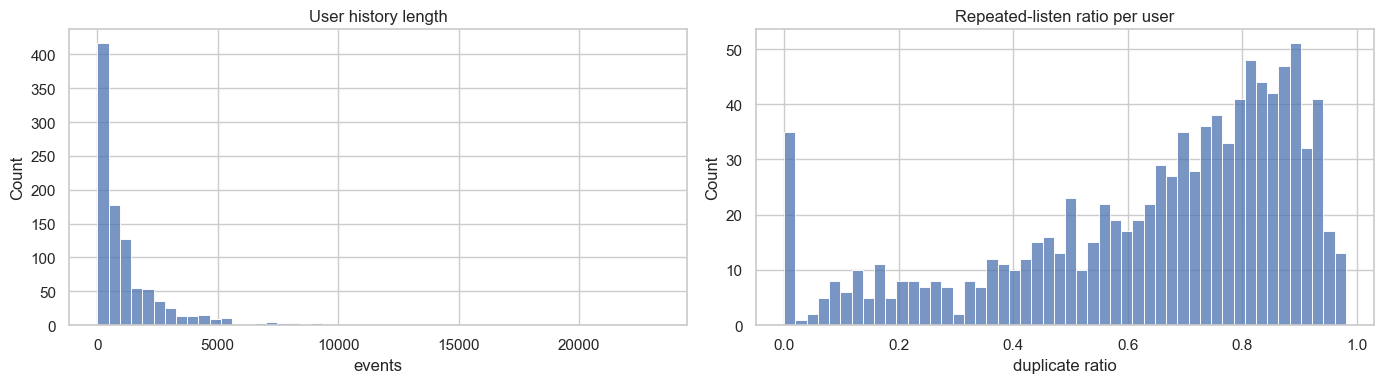

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(user_events['total_events'], bins=50, ax=axes[0])
axes[0].set_title('User history length')
axes[0].set_xlabel('events')

sns.histplot(user_events['duplicate_ratio'], bins=50, ax=axes[1])
axes[1].set_title('Repeated-listen ratio per user')
axes[1].set_xlabel('duplicate ratio')
plt.tight_layout()

In [12]:
split_table = history_df.groupby(['user_id', 'split']).size().unstack(fill_value=0)
train_counts = split_table['train'] if 'train' in split_table else pd.Series(0, index=split_table.index)
eval_counts = split_table['eval'] if 'eval' in split_table else pd.Series(0, index=split_table.index)

split_summary = pd.Series({
    'users_total': len(split_table),
    'users_train_only': ((train_counts > 0) & (eval_counts == 0)).sum(),
    'users_eval_only': ((eval_counts > 0) & (train_counts == 0)).sum(),
    'users_both': ((train_counts > 0) & (eval_counts > 0)).sum(),
})
display(split_summary.to_frame('value'))

,value
users_total,981
users_train_only,0
users_eval_only,9
users_both,972


## 6) Train/validation leakage audit for embedding training
The current training code does a random split over the triplet dataset. This section estimates how much user/track overlap that creates.


In [13]:
rng = np.random.default_rng(42)
perm = rng.permutation(len(triplets_df))
val_size = max(1, int(0.2 * len(triplets_df)))
val_idx = perm[:val_size]
train_idx = perm[val_size:]

train_triplets = triplets_df.iloc[train_idx]
val_triplets = triplets_df.iloc[val_idx]

train_users = set(train_triplets['user_id'])
val_users = set(val_triplets['user_id'])
train_tracks = set(pd.unique(pd.concat([train_triplets['anchor_idx'], train_triplets['pos_idx']], ignore_index=True)))
val_tracks = set(pd.unique(pd.concat([val_triplets['anchor_idx'], val_triplets['pos_idx']], ignore_index=True)))

leakage_df = pd.Series({
    'val_users_also_in_train_rate': len(train_users & val_users) / max(len(val_users), 1),
    'val_anchor_pos_tracks_also_in_train_rate': len(train_tracks & val_tracks) / max(len(val_tracks), 1),
})
display(leakage_df.to_frame('rate'))

,rate
val_users_also_in_train_rate,1.0000
val_anchor_pos_tracks_also_in_train_rate,0.9907


<!-- added:leakage-viz -->
### Visualize how much eval is replay versus discovery
These views complement the random triplet train/val audit by measuring how much of each user's eval set is already in their own training history.


In [ ]:
train_history = history_df[history_df['split'] == 'train']
eval_history = history_df[history_df['split'] == 'eval']
train_user_tracks = train_history.groupby('user_id')['track_idx'].apply(set).to_dict()

overlap_rows = []
for user_id, grp in eval_history.groupby('user_id'):
    eval_tracks = set(grp['track_idx'])
    train_tracks_user = train_user_tracks.get(user_id, set())
    overlap = eval_tracks & train_tracks_user
    overlap_rows.append({
        'user_id': user_id,
        'eval_unique_tracks': len(eval_tracks),
        'overlap_unique_tracks': len(overlap),
        'overlap_rate': len(overlap) / max(len(eval_tracks), 1),
    })

overlap_df = pd.DataFrame(overlap_rows)
row_overlap_rate = eval_history.set_index(['user_id', 'track_idx']).index.isin(train_history.set_index(['user_id', 'track_idx']).index).mean()

display(overlap_df['overlap_rate'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame('value'))
print(f'Row-level eval overlap rate: {row_overlap_rate:.2%}')
print(f'Users with any repeated eval track: {(overlap_df["overlap_unique_tracks"] > 0).mean():.2%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(overlap_df['overlap_rate'], bins=40, ax=axes[0], color='indianred')
axes[0].set_title('Per-user eval overlap with train history')
axes[0].set_xlabel('fraction of unique eval tracks already seen in train')

leakage_summary_plot = pd.DataFrame({
    'metric': ['row-level eval overlap', 'users with any overlap', 'triplet val users in train', 'triplet val tracks in train'],
    'rate': [
        row_overlap_rate,
        (overlap_df['overlap_unique_tracks'] > 0).mean(),
        len(train_users & val_users) / max(len(val_users), 1),
        len(train_tracks & val_tracks) / max(len(val_tracks), 1),
    ]
})
sns.barplot(data=leakage_summary_plot, x='rate', y='metric', ax=axes[1], palette='rocket')
axes[1].set_xlim(0, 1)
axes[1].set_title('Leakage summary across evaluation views')
axes[1].set_xlabel('rate')
axes[1].set_ylabel('')
plt.tight_layout()


## 7) Optional raw-event coverage and session health
This section is especially useful if you suspect the join or sessionizer is throwing away too much signal.


,value
matched_event_rate,0.0571
matched_events,"57,130.0000"
raw_events,"1,000,000.0000"
users_with_zero_matched_events,0.0000


,n_events,n_unique_tracks,repeated_track_rate
count,"10,892.0000","10,892.0000","10,892.0000"
mean,3.9266,3.2269,0.0960
std,5.4788,2.4433,0.2055
min,2.0000,1.0000,0.0000
25%,2.0000,2.0000,0.0000
50%,3.0000,2.0000,0.0000
75%,4.0000,4.0000,0.0000
90%,7.0000,6.0000,0.5000
95%,9.0000,8.0000,0.5000
99%,19.0000,13.0000,0.8571


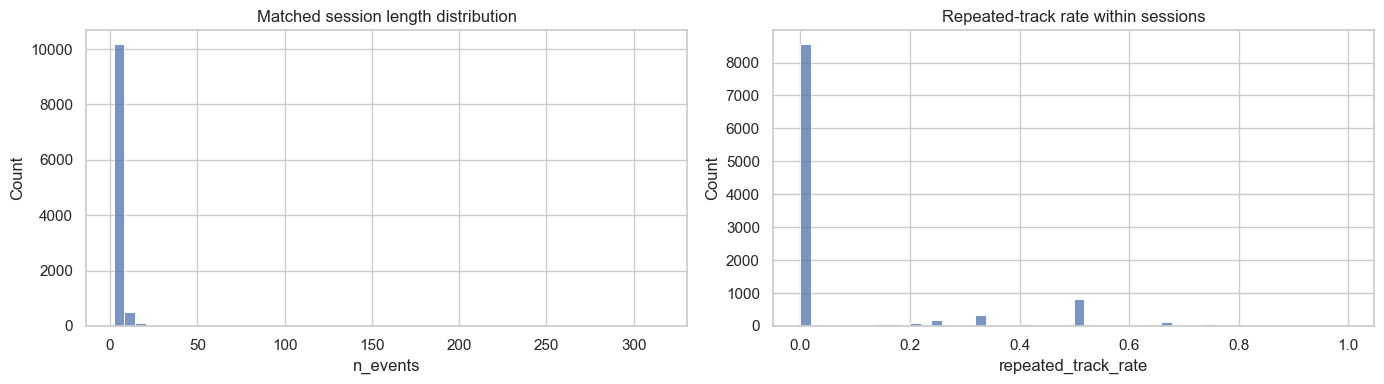

In [14]:
if raw_df is not None:
    lookup = set(zip(track_df['artist_norm'], track_df['track_norm']))
    raw_df['matched'] = list(zip(raw_df['artist_norm'], raw_df['track_norm']))
    raw_df['matched'] = raw_df['matched'].isin(lookup)

    coverage = pd.Series({
        'matched_event_rate': raw_df['matched'].mean(),
        'matched_events': raw_df['matched'].sum(),
        'raw_events': len(raw_df),
        'users_with_zero_matched_events': (raw_df.groupby('user_id')['matched'].mean() == 0).sum(),
    })
    display(coverage.to_frame('value'))

    matched = raw_df[raw_df['matched']].sort_values(['user_id', 'timestamp']).copy()
    matched['delta'] = matched.groupby('user_id')['timestamp'].diff()
    matched['new_session'] = matched['delta'].isna() | (matched['delta'] > pd.Timedelta(minutes=GAP_MINUTES))
    matched['session_id'] = matched.groupby('user_id')['new_session'].cumsum()

    sess = matched.groupby(['user_id', 'session_id']).agg(
        n_events=('track_norm', 'size'),
        n_unique_tracks=('track_norm', 'nunique')
    )
    sess = sess[sess['n_events'] >= MIN_SESSION_LENGTH].copy()
    sess['repeated_track_rate'] = 1 - (sess['n_unique_tracks'] / sess['n_events'])

    display(sess.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(sess['n_events'], bins=50, ax=axes[0])
    axes[0].set_title('Matched session length distribution')
    sns.histplot(sess['repeated_track_rate'], bins=50, ax=axes[1])
    axes[1].set_title('Repeated-track rate within sessions')
    plt.tight_layout()
else:
    print('Raw coverage/session analysis skipped.')

<!-- added:join-viz -->
### Visualize raw join coverage by user
If join coverage is poor, this will usually show a long tail of users for whom very little listening behavior survives the exact string match.


In [ ]:
if raw_df is not None:
    per_user_match = raw_df.groupby('user_id')['matched'].agg(['mean', 'size', 'sum']).rename(columns={
        'mean': 'match_rate', 'size': 'raw_events', 'sum': 'matched_events'
    })
    display(per_user_match['match_rate'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame('value'))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(per_user_match['match_rate'], bins=40, ax=axes[0], color='teal')
    axes[0].set_title('Per-user raw→catalog match rate')
    axes[0].set_xlabel('fraction of raw events that join into catalog')

    hardest_users = per_user_match.sort_values(['match_rate', 'raw_events']).head(15).reset_index()
    sns.barplot(data=hardest_users, x='match_rate', y='user_id', ax=axes[1], palette='crest')
    axes[1].set_title('Lowest raw→catalog match rates (sample-dependent)')
    axes[1].set_xlabel('match rate')
    axes[1].set_ylabel('user_id')
    plt.tight_layout()
else:
    print('Raw coverage visualization skipped.')


## 8) Feature-space sanity checks
Before blaming the model, check whether the engineered inputs themselves are redundant, skewed, or duplicated.


In [15]:
feature_only = track_df[feature_cols].copy()
display(feature_only.describe().T)

dup_feature_groups = feature_only.value_counts()
print('Duplicate feature groups:', int((dup_feature_groups > 1).sum()))
print('Tracks in duplicate feature groups:', int(dup_feature_groups[dup_feature_groups > 1].sum()))

,count,mean,std,min,25%,50%,75%,max
danceability,"81,206.0000",0.5593,0.1778,0.0000,0.4460,0.5730,0.6900,0.9850
energy,"81,206.0000",0.6351,0.2587,0.0000,0.4550,0.6780,0.8570,1.0000
loudness_norm,"81,206.0000",0.8568,0.0884,0.1745,0.8258,0.8790,0.9143,1.0000
acousticness,"81,206.0000",0.3296,0.3400,0.0000,0.0159,0.1900,0.6290,0.9960
instrumentalness,"81,206.0000",0.1848,0.3316,0.0000,0.0000,0.0001,0.1530,1.0000
liveness,"81,206.0000",0.2197,0.1983,0.0000,0.0985,0.1330,0.2830,1.0000
valence,"81,206.0000",0.4632,0.2634,0.0000,0.2410,0.4490,0.6760,0.9950
tempo_norm,"81,206.0000",0.4567,0.1660,0.0000,0.3299,0.4557,0.5562,1.0000
speechiness,"81,206.0000",0.0890,0.1167,0.0000,0.0361,0.0491,0.0871,0.9650
arousal,"81,206.0000",0.5972,0.1665,0.0000,0.5075,0.6330,0.7185,0.9780


Duplicate feature groups: 358
Tracks in duplicate feature groups: 742


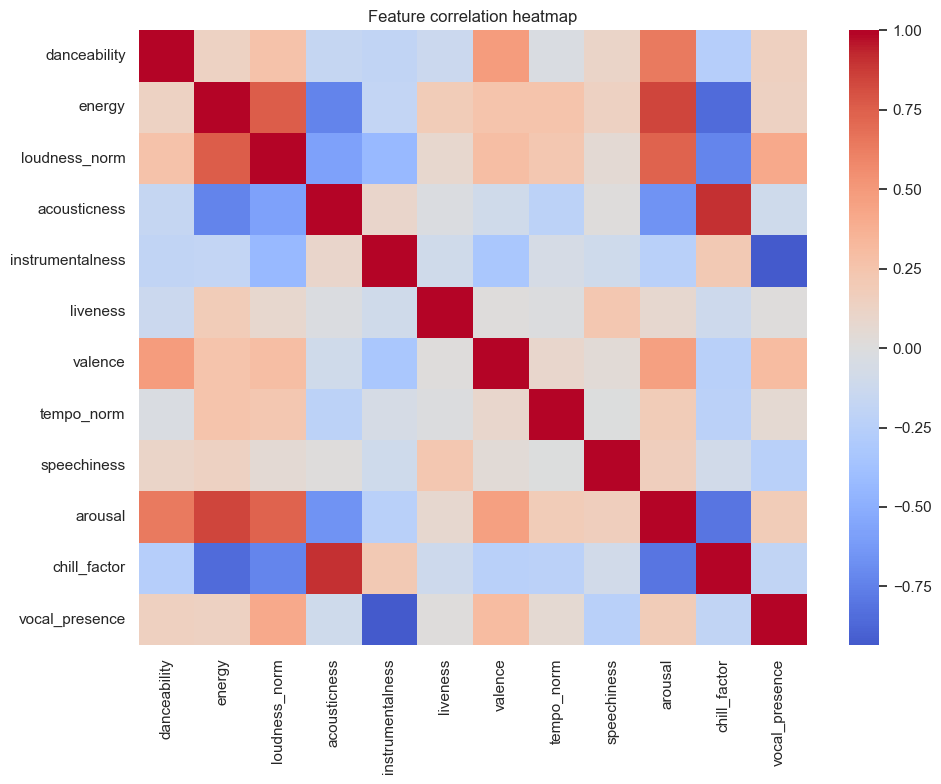

In [16]:
corr = feature_only.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature correlation heatmap')
plt.tight_layout()

<!-- added:spotify-dup-viz -->
### Raw Spotify duplicate-key audit
This checks whether the source catalog has multiple rows that collapse to the same normalized `(artist_norm, track_norm)` key, and whether those duplicates disagree on the audio features that survive into training.


In [ ]:
SPOTIFY_CSV_PATH = RAW / 'spotify_tracks.csv'
BASE_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

if SPOTIFY_CSV_PATH.exists():
    spotify_raw = pd.read_csv(SPOTIFY_CSV_PATH, low_memory=False)
    spotify_raw['artist_norm'] = spotify_raw['artists'].str.lower().str.strip()
    spotify_raw['track_norm'] = spotify_raw['track_name'].str.lower().str.strip()
    spotify_raw = spotify_raw.dropna(subset=BASE_FEATURES + ['artists', 'track_name'])

    dup_groups = spotify_raw.groupby(['artist_norm', 'track_norm'])
    dup_sizes = dup_groups.size()
    dup_sizes = dup_sizes[dup_sizes > 1]

    conflict_records = []
    for key, grp in dup_groups:
        if len(grp) <= 1:
            continue
        feature_variants = grp[BASE_FEATURES].drop_duplicates()
        if len(feature_variants) > 1:
            tempo_spread = grp['tempo'].max() - grp['tempo'].min()
            loudness_spread = grp['loudness'].max() - grp['loudness'].min()
            conflict_records.append({
                'artist_norm': key[0],
                'track_norm': key[1],
                'rows_in_group': len(grp),
                'feature_variants': len(feature_variants),
                'tempo_spread': tempo_spread,
                'loudness_spread': loudness_spread,
            })

    conflict_df = pd.DataFrame(conflict_records).sort_values(['feature_variants', 'tempo_spread'], ascending=False)
    print('Duplicate normalized key groups:', len(dup_sizes))
    print('Duplicate groups with conflicting feature vectors:', len(conflict_df))
    display(conflict_df.head(15))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(dup_sizes, bins=range(2, int(dup_sizes.max()) + 2), ax=axes[0], color='slateblue')
    axes[0].set_title('Duplicate normalized-key group sizes in raw Spotify catalog')
    axes[0].set_xlabel('rows per duplicate group')

    if not conflict_df.empty:
        sns.histplot(conflict_df['tempo_spread'], bins=40, ax=axes[1], color='darkorange')
        axes[1].set_title('Tempo disagreement across conflicting duplicate groups')
        axes[1].set_xlabel('tempo max-min within duplicate key')
    else:
        axes[1].text(0.5, 0.5, 'No conflicting duplicate groups found', ha='center', va='center')
        axes[1].set_axis_off()
    plt.tight_layout()
else:
    print('Raw Spotify duplicate audit skipped because spotify_tracks.csv was not found.')


## 9) Architecture-alignment checklist
Use this table as the final decision layer before retraining.


In [17]:
decision_table = pd.DataFrame([
    {
        'question': 'Are positives distinct from anchors?',
        'metric': 'anchor_eq_pos_rate',
        'value': (triplets_df['anchor_idx'] == triplets_df['pos_idx']).mean(),
        'good_if': '< 1%',
        'risk_if_high': 'Triplet loss gets weak or degenerate supervision'
    },
    {
        'question': 'Are negatives realistic?',
        'metric': 'negatives_never_seen_rate',
        'value': (~triplets_df['neg_idx'].isin(seen_tracks)).mean(),
        'good_if': 'moderate, not extreme',
        'risk_if_high': 'Negatives become too easy / out-of-distribution'
    },
    {
        'question': 'Is embedding validation clean?',
        'metric': 'val_users_also_in_train_rate',
        'value': len(train_users & val_users) / max(len(val_users), 1),
        'good_if': 'low',
        'risk_if_high': 'Validation overestimates generalization'
    },
    {
        'question': 'How much of the catalog gets positive supervision?',
        'metric': 'tracks_in_anchor_or_positive_fraction',
        'value': len(tracks_in_anchor_pos) / len(track_df),
        'good_if': 'higher is better',
        'risk_if_low': 'Most of catalog learned mostly as negatives'
    },
    {
        'question': 'Do repeated listens dominate user modeling?',
        'metric': 'median_duplicate_ratio_per_user',
        'value': user_events['duplicate_ratio'].median(),
        'good_if': 'depends on product goal',
        'risk_if_high': 'Personas may model replay loops more than taste breadth'
    },
])
display(decision_table)

,question,metric,value,good_if,risk_if_high,risk_if_low
0,Are positives distinct from anchors?,anchor_eq_pos_rate,0.0982,< 1%,Triplet loss gets weak or degenerate supervision,NaN
1,Are negatives realistic?,negatives_never_seen_rate,0.8909,"moderate, not extreme",Negatives become too easy / out-of-distribution,NaN
2,Is embedding validation clean?,val_users_also_in_train_rate,1.0000,low,Validation overestimates generalization,NaN
3,How much of the catalog gets positive supervis...,tracks_in_anchor_or_positive_fraction,0.1006,higher is better,NaN,Most of catalog learned mostly as negatives
4,Do repeated listens dominate user modeling?,median_duplicate_ratio_per_user,0.7201,depends on product goal,Personas may model replay loops more than tast...,NaN


## 10) What to do with the results
If the metrics are bad, the likely next fixes are:

1. **Triplet builder**: exclude identical `anchor_idx == pos_idx` pairs
2. **Negative sampling**: sample from listened tracks or hard-neighbor tracks, not uniformly from the whole catalog
3. **Embedding validation**: validate on temporally held-out triplets, not random rows from the same triplet pool
4. **Persona/emotion scoring**: stop assuming a latent embedding dimension still corresponds to raw valence
5. **Replay handling**: decide whether repeated listens should be downweighted, capped, or preserved intentionally
